In [111]:
import pandas as pd
import os

In [112]:
df = pd.read_csv("../data/raw/paris_housing_prices_dataset.csv")

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   object 
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   object 
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   object 
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 93.9+ KB


In [114]:
df.sample(10)

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
932,P10932,20,Apartment,30,2,0,2020,New,7.14,473548.96
696,P10696,15,Loft,54,2,3,1965,Needs Renovation,4.07,486798.37
293,P10293,5,Loft,97,5,7,1903,New,9.91,1727959.03
275,P10275,15,Loft,24,3,9,1942,New,5.39,319303.02
153,P10153,18,Studio,178,4,4,1997,New,3.13,2953758.50
670,P10670,20,Studio,180,3,0,2022,Good,12.48,2814568.45
1026,P11026,18,Loft,182,5,3,1953,Renovated,8.70,1740691.24
173,P10173,16,Apartment,81,3,7,2011,Needs Renovation,12.18,1282469.22
864,P10864,20,Apartment,88,3,6,2006,Renovated,0.68,1407847.21
52,P10052,17,Loft,40,3,7,1862,New,1.68,442979.33


## **Handling missing values**

In [115]:
df.isnull().sum()

Property_ID              0
Arrondissement           0
Property_Type            0
Size_sqm                 0
Rooms                    0
Floor                    0
Year_Built               0
Condition                0
Distance_to_Center_km    0
Price_EUR                0
dtype: int64

**There are no missing values in columns so we do not have to work with that**

## **Encoding**

**The column "Condition" can be encoded with ordinal encoding**

In [116]:
condition_mapping = {
    "Needs Renovation" : 0,
    "Good" : 1,
    "Renovated" : 2,
    "New" : 3
}

df["Condition"] = df['Condition'].map(condition_mapping)


df.drop("Property_ID", axis=1, inplace=True)  # no predictive feature 

dummies = pd.get_dummies(df['Property_Type'], prefix='Location', dtype=int) 
df = pd.concat([df.drop(columns=['Property_Type']), dummies], axis=1)


In [117]:
df.sample(20)

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR,Location_Apartment,Location_Loft,Location_Penthouse,Location_Studio
596,12,27,3,9,1938,2,2.78,524599.35,0,1,0,0
398,1,50,5,9,2007,1,1.03,441374.81,0,0,0,1
429,10,122,4,7,1980,1,13.26,1435785.00,0,0,1,0
168,13,92,3,1,1962,0,6.31,1236430.87,1,0,0,0
477,6,166,2,4,1856,1,2.57,1660385.52,0,0,0,1
14,20,137,5,9,1890,1,13.77,2618838.64,0,0,1,0
511,5,158,4,9,1862,0,10.17,1539292.59,1,0,0,0
320,10,144,4,4,1857,0,13.26,2535016.05,1,0,0,0
205,15,27,5,2,1972,2,14.97,340404.30,0,1,0,0
597,2,186,2,2,1906,3,12.05,3432996.12,0,1,0,0


**Adding cleaned and encoded dataset to preprocessed folder**

In [119]:
output_folder = "../data/preprocessed"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "cleaned_encoded.csv")
df.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: ../data/preprocessed\cleaned_encoded.csv


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

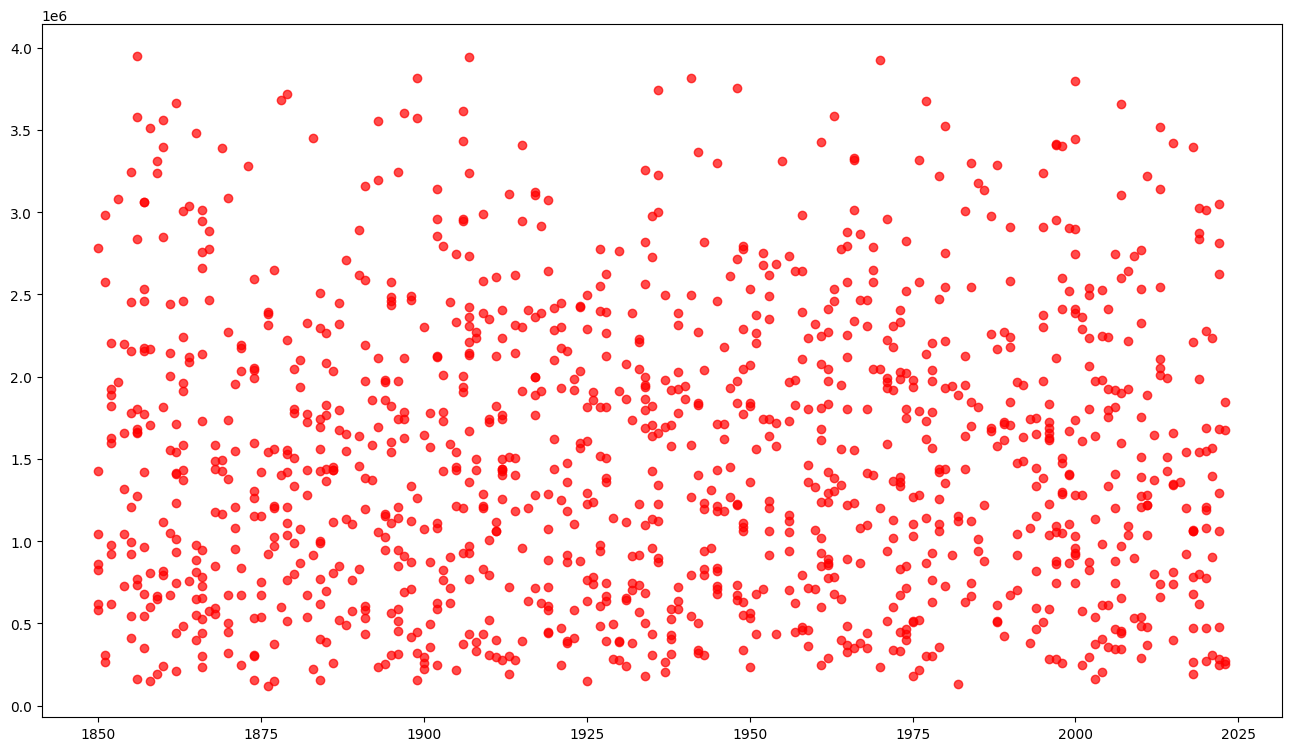

In [126]:
plt.figure(figsize=(16,9))
plt.scatter(df['Year_Built'], df['Price_EUR'], color="red", alpha=0.7)
plt.show()

<Axes: >

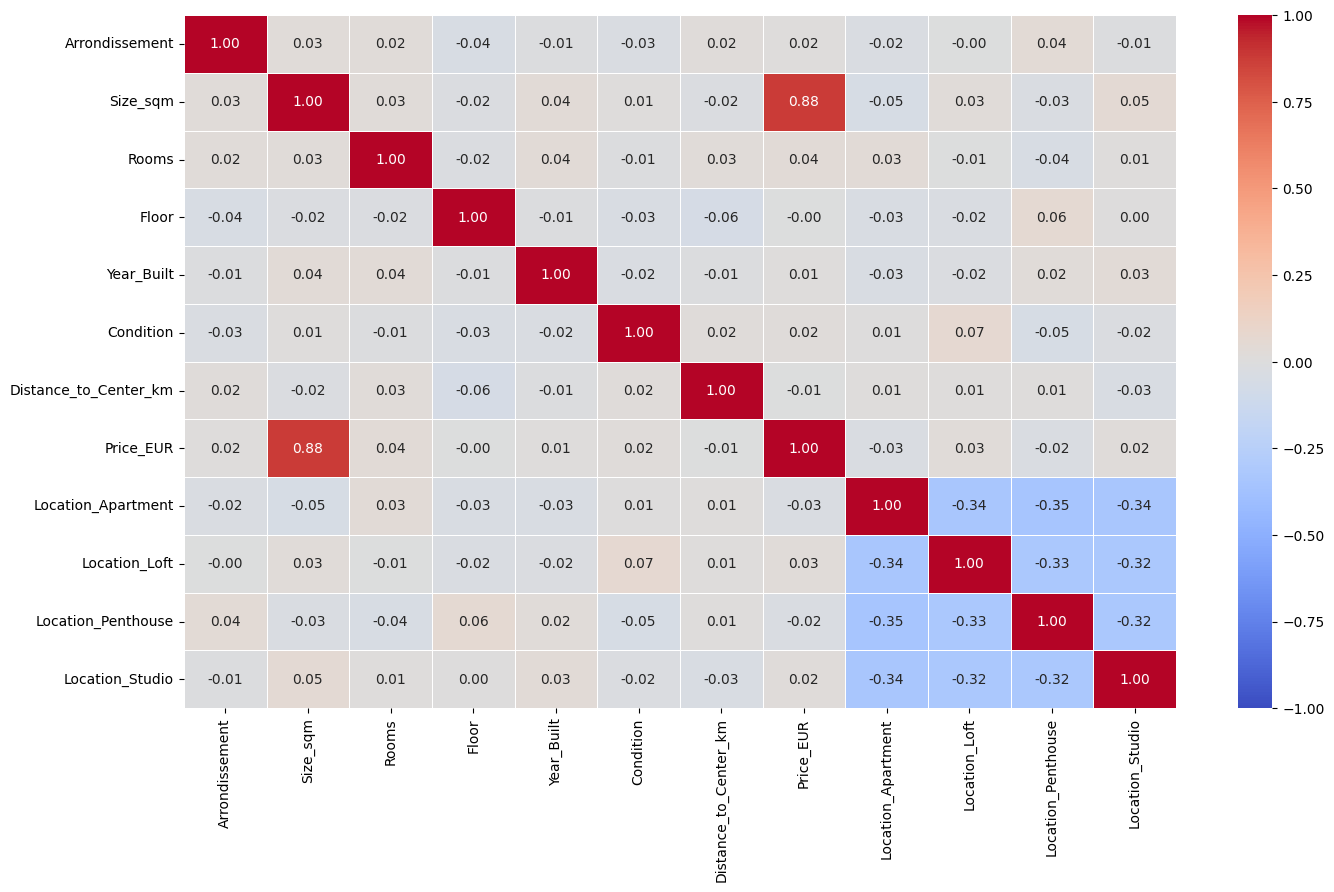

In [128]:
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            vmin=-1, vmax=1
            )

## **Regression tasks using various algorithms**

In [130]:
df.sample(1)

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR,Location_Apartment,Location_Loft,Location_Penthouse,Location_Studio
329,7,165,2,8,1934,2,5.52,1996515.51,0,0,0,1


In [131]:
x = df.drop("Price_EUR", axis=1)
y = df["Price_EUR"]

### **Linear Regression**

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr = LinearRegression()

lr.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)



324063.9835412512
167839392410.44772
409682.0625929914
0.7830899567706062


## **Ridge Model**

In [149]:
from sklearn.linear_model import Ridge

rm = Ridge(alpha=0.01)

rm.fit(x_train_scaled, y_train)

y_pred = rm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

323256.733016624
167885968245.4526
409738.9025287355
0.7830297637119966


## **Lasso Model**

In [156]:
from sklearn.linear_model import Lasso

lm = Lasso(alpha=1)

lm.fit(x_train_scaled, y_train)

y_pred = lm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

323256.22638535715
167885788333.35138
409738.682983864
0.7830299962244068


## **SVM**

In [ ]:
from sklearn.svm import SVR

svm = SVR(
    kernel="rbf",    
    C=1.0,            
    gamma="scale",    
    epsilon=0.1       
)

svm.fit(x_train_scaled, y_train)

y_pred = svm.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

733452.0856527858
803394538083.0873
896322.7867699713
-0.03828035530360796


## **Decision Tree**

In [161]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

420319.663
351562297578.6341
592926.890584863
0.5456525904293035


## **Random Forest Regressor**

In [162]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

330130.51456708333
178261074995.0754
422209.7523685063
0.7696213211452672


In [164]:
from tabulate import tabulate

columns = ["Algorithm", "Mean Absolute Error", "Mean Squared Error", "Root Mean Squared Error", "R2_score"]

results = [["Linear Regression", 324063.9, 167839392410.4, 409682.06, 0.783],
           ["Ridge Model", 323256.73, 167885968245.45, 409738.90, 0.783],
           ["Lasso Model", 323256.73, 167885968245.45, 409738.90, 0.783],
           ["SVM", 732923.94, 802303479293.09, 895713.949, -0.036],
           ["Decision Tree Regressor", 420319.663, 351562297578.6341, 592926.890, 0.545],
           ["Random Forest Regressor", 330130.51, 178261074995.07, 422209.75, 0.769]]

table = tabulate(results, headers = columns, tablefmt = 'grid', floatfmt='.2f')
print(table)

+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Algorithm               |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
+=========================+=======================+======================+===========================+============+
| Linear Regression       |             324063.90 |      167839392410.40 |                 409682.06 |       0.78 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Ridge Model             |             323256.73 |      167885968245.45 |                 409738.90 |       0.78 |
+-------------------------+-----------------------+----------------------+---------------------------+------------+
| Lasso Model             |             323256.73 |      167885968245.45 |                 409738.90 |       0.78 |
+-------------------------+-----------------------+---------------------

    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Algorithm               |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
    +=========================+=======================+======================+===========================+============+
    | Linear Regression       |             324063.90 |      167839392410.40 |                 409682.06 |       0.78 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Ridge Model             |             323256.73 |      167885968245.45 |                 409738.90 |       0.78 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Lasso Model             |             323256.73 |      167885968245.45 |                 409738.90 |       0.78 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | SVM                     |             732923.94 |      802303479293.09 |                 895713.95 |      -0.04 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Decision Tree Regressor |             420319.66 |      351562297578.63 |                 592926.89 |       0.55 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+
    | Random Forest Regressor |             330130.51 |      178261074995.07 |                 422209.75 |       0.77 |
    +-------------------------+-----------------------+----------------------+---------------------------+------------+